In [ ]:
!mkdir -p /content/fashion_dataset
!unzip -q "/content/drive/MyDrive/Colab Notebooks/Glance Intern/val_test2020.zip" -d /content/fashion_dataset

In [ ]:
import os

image_dir='/content/fashion_dataset'
valid_extensions=('.jpg', '.jpeg', '.png', '.webp')

image_paths=[]
for root,dirs,files in os.walk(image_dir):
    for file in files:
        if file.lower().endswith(valid_extensions):
            image_paths.append(os.path.join(root, file))

print(f"Success! Total images extracted: {len(image_paths)}")

Success! Total images extracted: 3200


In [ ]:
!pip install -q transformers pillow chromadb sentence-transformers torch torchvision tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently

In [ ]:
import os
import torch
import chromadb
from PIL import Image
from tqdm import tqdm
from transformers import BlipProcessor, BlipForConditionalGeneration
from transformers import AutoProcessor, Blip2ForConditionalGeneration

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
processor=AutoProcessor.from_pretrained("Salesforce/blip2-opt-2.7b")
model=Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [ ]:
chroma_client=chromadb.PersistentClient(path="/content/chroma_db")
try:
    chroma_client.delete_collection(name="fashion_index")
except Exception:
    pass

collection=chroma_client.get_or_create_collection(name="fashion_index")

In [ ]:
image_dir='/content/fashion_dataset'
valid_extensions=('.jpg', '.jpeg', '.png', '.webp')
image_paths=[os.path.join(r, f) for r, d, fs in os.walk(image_dir) for f in fs if f.lower().endswith(valid_extensions)]

In [ ]:
len(image_paths)

3200

In [ ]:
docs=[]
metadatas=[]
ids=[]

questions=[
    "Question: What color and type of upper clothing is the person wearing? Answer:",
    "Question: What color and type of lower clothing is the person wearing? Answer:",
    "Question: What is the environment or setting behind the person? Answer:",
    "Question: What action is the person performing, such as standing, sitting, or walking? Answer:"
]

for i,img_path in enumerate(tqdm(image_paths)):
    try:
        raw_image=Image.open(img_path).convert('RGB')
        answers=[]

        for q in questions:
            inputs=processor(raw_image, text=q, return_tensors="pt").to(device, torch.float16)
            generated_ids=model.generate(**inputs, max_new_tokens=20)
            answer=processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
            answers.append(answer)

        rich_caption=f"Upper clothing: {answers[0]}. Lower clothing: {answers[1]}. Environment: {answers[2]}. Action: {answers[3]}."
        docs.append(rich_caption)
        metadatas.append({"image_path": img_path})
        ids.append(f"img_{i}")

        if len(docs)==50 or i==len(image_paths)-1:
            collection.add(documents=docs,metadatas=metadatas,ids=ids)
            docs,metadatas,ids=[], [], []

    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        continue

print("\nBLIP-2 High-Precision Indexing Complete!")


  2%|▏         | 49/3200 [00:58<56:02,  1.07s/it]

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   0%|          | 0.00/79.3M [00:00<?, ?iB/s]

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   0%|          | 51.0k/79.3M [00:00<04:35, 302kiB/s]

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   0%|          | 339k/79.3M [00:00<01:13, 1.12MiB/s]

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   1%|          | 969k/79.3M [00:00<00:29, 2.76MiB/s]

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   4%|▎         | 2.82M/79.3M [00:00<00:11, 6.93MiB/s]

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:   8%|▊         | 6.21M/79.3M [00:00<00:05, 14.4MiB/s]

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:  12%|█▏        | 9.68M/79.3M [00:00<00:04, 17.9MiB/s]

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz:  17%|█▋        | 13.4M/79.3M [00:00<00:03, 22.8MiB/s]

/root/.cache/chroma/onnx


BLIP-2 High-Precision Indexing Complete!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from IPython.display import display

chroma_client=chromadb.PersistentClient(path="/content/chroma_db")
collection=chroma_client.get_collection(name="fashion_index")

In [ ]:
collection=chroma_client.get_collection(name="fashion_index")
print(f"Total items indexed in Vector DB: {collection.count()}")

if collection.count()>0:
    print("\nSample database entry:")
    peek=collection.peek(limit=2)
    print("Captions:",peek['documents'])
    print("Metadata:",peek['metadatas'])
else:
    print("\nYour vector database is completely empty. The indexing step did not save the items properly.")

Total items indexed in Vector DB: 3200

Sample database entry:
Captions: ['Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: Black and black. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: Black and black. Environment: Question: What is the environment or setting behind the person? Answer: The environment or setting behind the person is the environment or setting behind the person. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: Walking.', 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: brown. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: brown. Environment: Question: What is the environment or setting behind the person? Answer: The environment or setting behind the person is the environment or setting. Action: Question: What action is the perso

In [ ]:
def search_fashion_robust(query, top_k=3):
    print(f"Searching for: '{query}'\n")

    results=collection.query(
        query_texts=[query],
        n_results=top_k
    )

    captions=results['documents'][0]
    metadatas=results['metadatas'][0]
    distances=results['distances'][0]

    for i in range(len(metadatas)):
        img_path=metadatas[i]['image_path']
        caption=captions[i]
        dist=distances[i]

        print(f"Match #{i+1} (Distance: {dist:.4f})")
        print(f"Generated Caption: '{caption}'")
        print(f"Image Path: {img_path}")

        if os.path.exists(img_path):
            try:
                img=Image.open(img_path)
                img.thumbnail((300, 300))
                display(img)
            except Exception as e:
                print(f"Error displaying image: {e}")
        else:
            print(f"Error: File does not exist at path: {img_path}")
        print("-" * 50)

Searching for: 'A person in a bright yellow raincoat.'

Match #1 (Distance: 1.2782)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: Yellow. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: Yellow. Environment: Question: What is the environment or setting behind the person? Answer: The environment or setting behind the person is a bright yellow dress. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: Standing.'
Image Path: /content/fashion_dataset/test/b94d99465abae434937344cf5eed85af.jpg


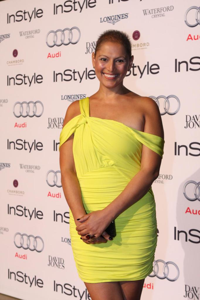

--------------------------------------------------
Match #2 (Distance: 1.2793)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: yellow. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: yellow. Environment: Question: What is the environment or setting behind the person? Answer: a yellow coat. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: walking.'
Image Path: /content/fashion_dataset/test/1ae9cdebd762234889e60f2c0d07a768.jpg


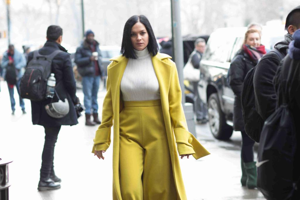

--------------------------------------------------
Match #3 (Distance: 1.2874)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: A turquoise jacket and a yellow skirt. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: A turquoise jacket and a yellow skirt. Environment: Question: What is the environment or setting behind the person? Answer: The environment or setting behind the person is the environment or setting. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: The person is standing.'
Image Path: /content/fashion_dataset/test/e91677348e11b75ee3ccdb9c8fd78032.jpg


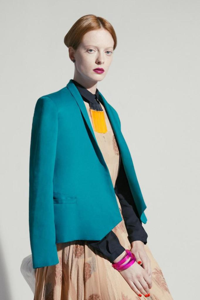

--------------------------------------------------


In [ ]:
search_fashion_robust("A person in a bright yellow raincoat.", top_k=3)

Searching for: 'Professional man in business attire inside a modern office.'

Match #1 (Distance: 1.2943)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: A light green dress with a white belt. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: green. Environment: Question: What is the environment or setting behind the person? Answer: The environment or setting behind the person is the most important factor in the success of the fashion show. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: The person performing is standing.'
Image Path: /content/fashion_dataset/test/a0aedf945aef6f2eb6578dd749e92545.jpg


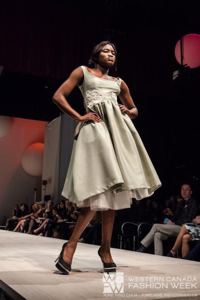

--------------------------------------------------
Match #2 (Distance: 1.3078)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: The person is wearing a wedding dress. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: The person is wearing a white dress with a black belt. Environment: Question: What is the environment or setting behind the person? Answer: The environment or setting behind the person is the room. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: The person performing the action is the actor.'
Image Path: /content/fashion_dataset/test/8b841ec093878d46cffc502948580985.jpg


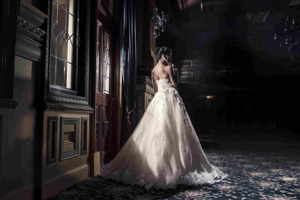

--------------------------------------------------
Match #3 (Distance: 1.3079)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: The person is wearing a white dress with a lace bodice and a lace skirt. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: The person is wearing a white dress with a lace bodice and a lace skirt. Environment: Question: What is the environment or setting behind the person? Answer: The environment or setting behind the person is the lighting, the background, the time of day, the. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: The person performing the action is the actor.'
Image Path: /content/fashion_dataset/test/8e13b4bba964e3d1fc2eba6e30975f06.jpg


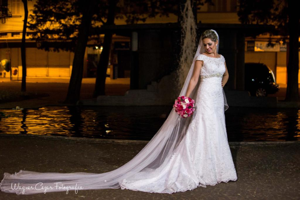

--------------------------------------------------


In [ ]:
search_fashion_robust("Professional man in business attire inside a modern office.", top_k=3)

Searching for: 'Someone wearing a blue shirt sitting on a park bench.'

Match #1 (Distance: 1.1596)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: The person is wearing a hat, a jacket, and jeans. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: The person is wearing a blue shirt and a blue hat. Environment: Question: What is the environment or setting behind the person? Answer: The mountains and the lake. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: The person is taking a photo of the lake.'
Image Path: /content/fashion_dataset/test/0bf1bfb33db3cee939902582642ac1bb.jpg


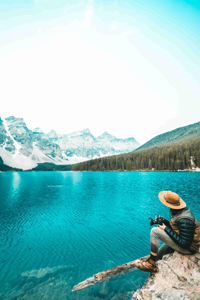

--------------------------------------------------
Match #2 (Distance: 1.1667)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: The person is wearing a light blue shirt and a light blue skirt. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: The person is wearing a light blue shirt and a light blue skirt. Environment: Question: What is the environment or setting behind the person? Answer: The environment or setting behind the person is the lake. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: Sitting.'
Image Path: /content/fashion_dataset/test/ee95f14ac534d52c329935bddf2d6e91.jpg


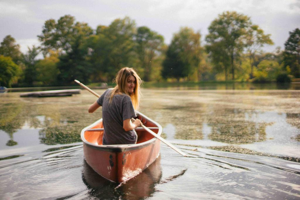

--------------------------------------------------
Match #3 (Distance: 1.1990)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: he is wearing a light blue shirt and dark blue jeans. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: the person is wearing a light blue shirt and dark blue pants. Environment: Question: What is the environment or setting behind the person? Answer: the person. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: Sitting.'
Image Path: /content/fashion_dataset/test/fca7000d1b2db825d5b56db79b95c61c.jpg


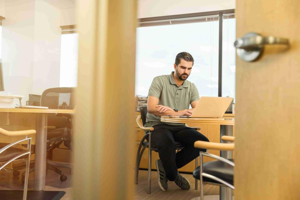

--------------------------------------------------


In [ ]:
search_fashion_robust("Someone wearing a blue shirt sitting on a park bench.", top_k=3)

Searching for: 'A red tie and a white shirt in a formal setting.'

Match #1 (Distance: 1.0061)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: The person is wearing a white dress with a lace bodice and a lace skirt. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: The person is wearing a white dress with a lace bodice and a lace skirt. Environment: Question: What is the environment or setting behind the person? Answer: The environment or setting behind the person is the most important factor in the overall look of the wedding. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: Standing.'
Image Path: /content/fashion_dataset/test/e0dc7eeba14882ae1a95585804a5d666.jpg


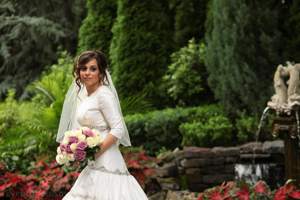

--------------------------------------------------
Match #2 (Distance: 1.0376)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: The person is wearing a white dress with a white blouse and a white skirt. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: The person is wearing a white dress with a white blouse and a white skirt. Environment: Question: What is the environment or setting behind the person? Answer: The environment or setting behind the person is the most important factor in the wedding photography. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: Standing.'
Image Path: /content/fashion_dataset/test/dd1e31a6f4be99d669112b30d6ce476b.jpg


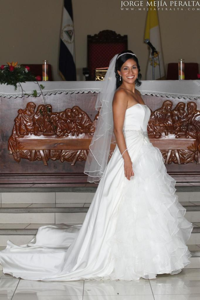

--------------------------------------------------
Match #3 (Distance: 1.0495)
Generated Caption: 'Upper clothing: Question: What color and type of upper clothing is the person wearing? Answer: A white dress with a lace overlay. Lower clothing: Question: What color and type of lower clothing is the person wearing? Answer: white, long sleeve, lace, and lace. Environment: Question: What is the environment or setting behind the person? Answer: The environment or setting behind the person is the most important factor in determining the success of a wedding dress. Action: Question: What action is the person performing, such as standing, sitting, or walking? Answer: The person performing is standing.'
Image Path: /content/fashion_dataset/test/69b505aa605512169cdbf485fc8b9718.jpg


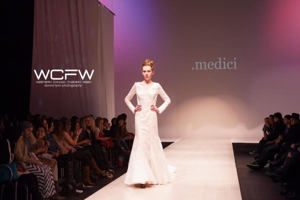

--------------------------------------------------


In [ ]:
search_fashion_robust("A red tie and a white shirt in a formal setting.", top_k=3)